# Deep Hedging Frictions 

Copyright (c) jfyo2 2026. This project is licensed under the MIT License. 


In [89]:
# Add project folder to PATH so this notebook can read things in src
import sys, os
sys.path.append(os.path.abspath('..'))

# Import main libraries 
import math 
import numpy as np
import matplotlib.pyplot as plt
import importlib
import pandas as pd 
import torch 
import torch.nn as nn 

# Import project libraries 
from src import gbm, pricer, heston, deltahedge, deephedging 
from src.config import * 


importlib.reload(gbm) # Tell gbm to reload whenever updated 
importlib.reload(pricer)
importlib.reload(heston)
importlib.reload(deltahedge) 
importlib.reload(deephedging)

print("Import complete.")


Import complete.


## 1. Option Pricing under Geometric Brownian Motion


In [37]:
NO_PATHS = 50_000 # Number of probabilistic asset paths to simulate

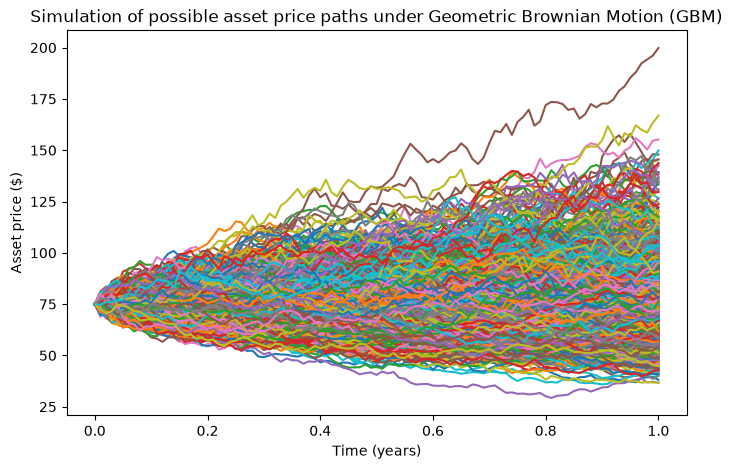

In [38]:
RNG = np.random.default_rng(42)

(ts, paths_gbm) = gbm.geometricBrownianMotion(RNG, NO_PATHS, S_0, R, SIGMA, 1, STEPS)

# Plot first 1k asset paths and add to 'paths' list for later analysis
fig, ax = plt.subplots(1, 1, figsize=(8,5))
for GBM in paths_gbm[:1000]:
    ax.plot(ts, GBM)
    ax.set_xlabel("Time (years)")
    ax.set_ylabel("Asset price ($)")
    ax.set_title("Simulation of possible asset price paths under Geometric Brownian Motion (GBM)")

# Convert 'paths' list to a numpy array for consistency
paths_array_gbm = np.array(paths_gbm)


In [26]:
time = 1 # Time to calculate the option price at 
OP_mc = pricer.option_price_mc(ts, paths_array_gbm, time, K, R)

print(f'The price of a European call option at time %.2f for the simulated asset is estimated \nas %.4f by Monte-Carlo.'%(T,OP_mc))


The price of a European call option at time 1.00 for the simulated asset is estimated 
as 9.3538 by Monte-Carlo.


In [27]:
OP_bsm = pricer.option_price_bsm(S_0, K, T, R, SIGMA)

print(f'The Black-Scholes-Merton theoretical price of a European call option at time %.2f \nfor the simulated GBM asset is %.4f'%(T,OP_bsm))

direction = 'higher' if OP_mc > OP_bsm else 'lower'
distance = np.abs(OP_mc - OP_bsm)
print(f'The Monte-Carlo estimate is %.4f %s than the theoretical BSM price.'%(distance, direction))

The Black-Scholes-Merton theoretical price of a European call option at time 1.00 
for the simulated GBM asset is 9.2520
The Monte-Carlo estimate is 0.1018 higher than the theoretical BSM price.


## 2. The Heston Model

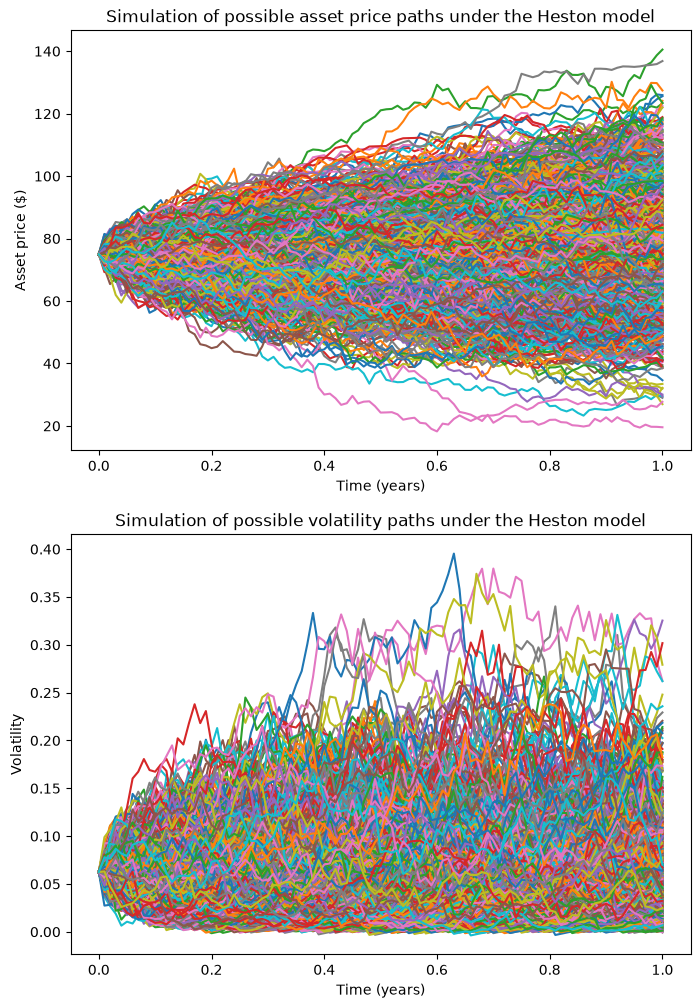

In [39]:
# Plot asset paths and add to 'paths'/'vol' lists for later analysis
fig, ax = plt.subplots(2, 1, figsize=(8,12))
(t, paths_heston, vols) = heston.hestonSim(RNG, NO_PATHS, S_0, NU_0, R, KAPPA, THETA, XI, RHO, T, STEPS)

# plot the first 1k paths 
for S in paths_heston[:1000]:
    ax[0].plot(t, S)
    ax[0].set_xlabel("Time (years)")
    ax[0].set_ylabel("Asset price ($)")
    ax[0].set_title("Simulation of possible asset price paths under the Heston model")

for nu in vols[:1000]:
    ax[1].plot(t, nu)
    ax[1].set_xlabel("Time (years)")
    ax[1].set_ylabel("Volatility")
    ax[1].set_title("Simulation of possible volatility paths under the Heston model")

# Convert 'paths' list to a numpy array for later
paths_array_heston = np.array(paths_heston)
vols_array = np.array(vols)

In [28]:
OP_heston_mc = pricer.option_price_mc(ts, paths_array_heston, T, K, R)

print(f'The price of a European call option at time %.2f for the simulated Heston asset is estimated \nas %.4f by Monte-Carlo.'%(T,OP_heston_mc))
direction = 'higher' if OP_heston_mc > OP_bsm else 'lower'
distance = np.abs(OP_heston_mc - OP_bsm)
print(f'The Monte-Carlo estimate is %.4f %s than the theoretical BSM price.'%(distance, direction))

The price of a European call option at time 1.00 for the simulated Heston asset is estimated 
as 9.0533 by Monte-Carlo.
The Monte-Carlo estimate is 0.1987 lower than the theoretical BSM price.


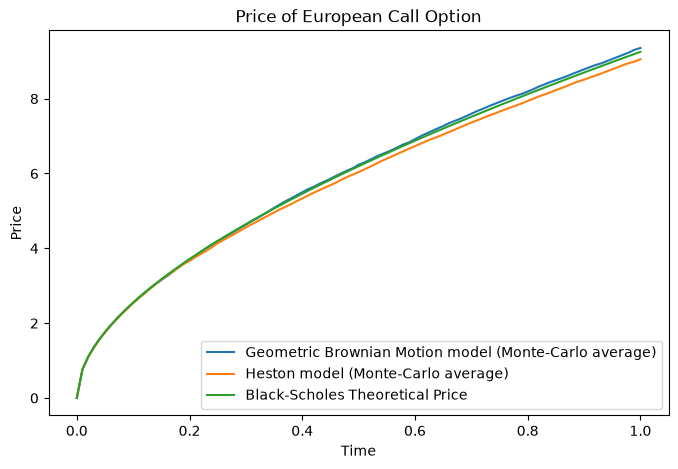

In [40]:
# Compute Monte Carlo price paths for GBM and Heston 
gbm_call_price_process = []
heston_call_price_process = []
bsm_call_price_process = []

# Computation for GBM
for time in ts:
    p = pricer.option_price_mc(ts, paths_array_gbm, time, K, R)
    gbm_call_price_process.append(p)

# Computation for Heston
for time in t:
    p = pricer.option_price_mc(t, paths_array_heston, time, K, R)
    heston_call_price_process.append(p)

tt = np.linspace(0, T, STEPS + 1)
for time in tt:
    # note Black-Scholes doesn't work at T=0 since we divide by T
    if time == 0:
        bsm_call_price_process.append(0)
    else:
        p = pricer.option_price_bsm(S_0, K, time, R, SIGMA)
        bsm_call_price_process.append(p)

fig, ax = plt.subplots(1, 1, figsize=(8,5))
ax.plot(ts, gbm_call_price_process, label='Geometric Brownian Motion model (Monte-Carlo average)')
ax.plot(t, heston_call_price_process, label='Heston model (Monte-Carlo average)')
ax.plot(tt, bsm_call_price_process, label='Black-Scholes Theoretical Price')
ax.set_title("Price of European Call Option")
ax.set_xlabel("Time")
ax.set_ylabel("Price")
ax.legend()
plt.show()

## 3. Classic Delta Hedging

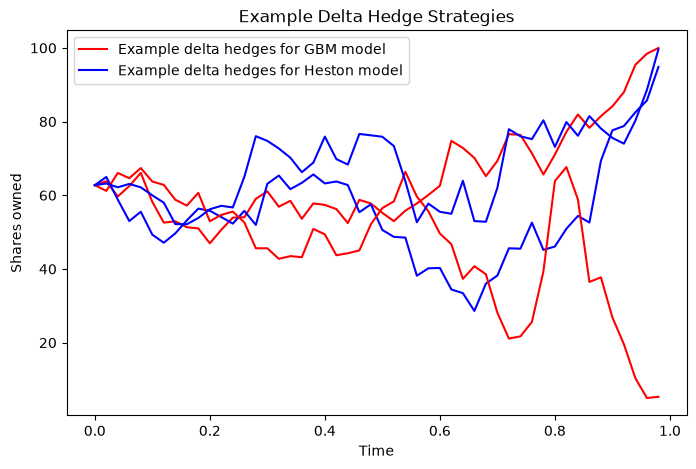

In [41]:
PATHS_TO_TEST = 2

test_gbm_paths = np.array(paths_array_gbm[0:PATHS_TO_TEST])
test_heston_paths = np.array(paths_array_heston[0:PATHS_TO_TEST])

t1, gbm_delta_hedge = deltahedge.delta_hedge_batch(test_gbm_paths, K, R, SIGMA, CALLS_SOLD, T, UPDATE_INTERVAL)
t2, heston_delta_hedge = deltahedge.delta_hedge_batch(test_heston_paths, K, R, SIGMA, CALLS_SOLD, T, UPDATE_INTERVAL)

fig, ax = plt.subplots(1, 1, figsize=(8,5))

for i in range(PATHS_TO_TEST):
    ax.plot(t1, gbm_delta_hedge[i], label='Example delta hedges for GBM model', color='r')
    ax.plot(t2, heston_delta_hedge[i], label='Example delta hedges for Heston model', color='b')

ax.set_title("Example Delta Hedge Strategies")
ax.set_xlabel("Time")
ax.set_ylabel("Shares owned")

# short script for grouping labels together, see https://stackoverflow.com/a/36189073
handles, labels = plt.gca().get_legend_handles_labels()
labels, ids = np.unique(labels, return_index=True)
handles = [handles[i] for i in ids]
ax.legend(handles, labels, loc='best')

plt.show()


In [42]:
C_0 = pricer.option_price_bsm(S_0, K, T, R, SIGMA)
COST_RATE = 0.001

gbm_pnl = deltahedge.delta_hedge_pnl(paths_array_gbm, S_0, C_0, K, R, SIGMA, CALLS_SOLD, COST_RATE, T, UPDATE_INTERVAL)
heston_pnl = deltahedge.delta_hedge_pnl(paths_array_heston, S_0, C_0, K, R, SIGMA, CALLS_SOLD, COST_RATE, T, UPDATE_INTERVAL)


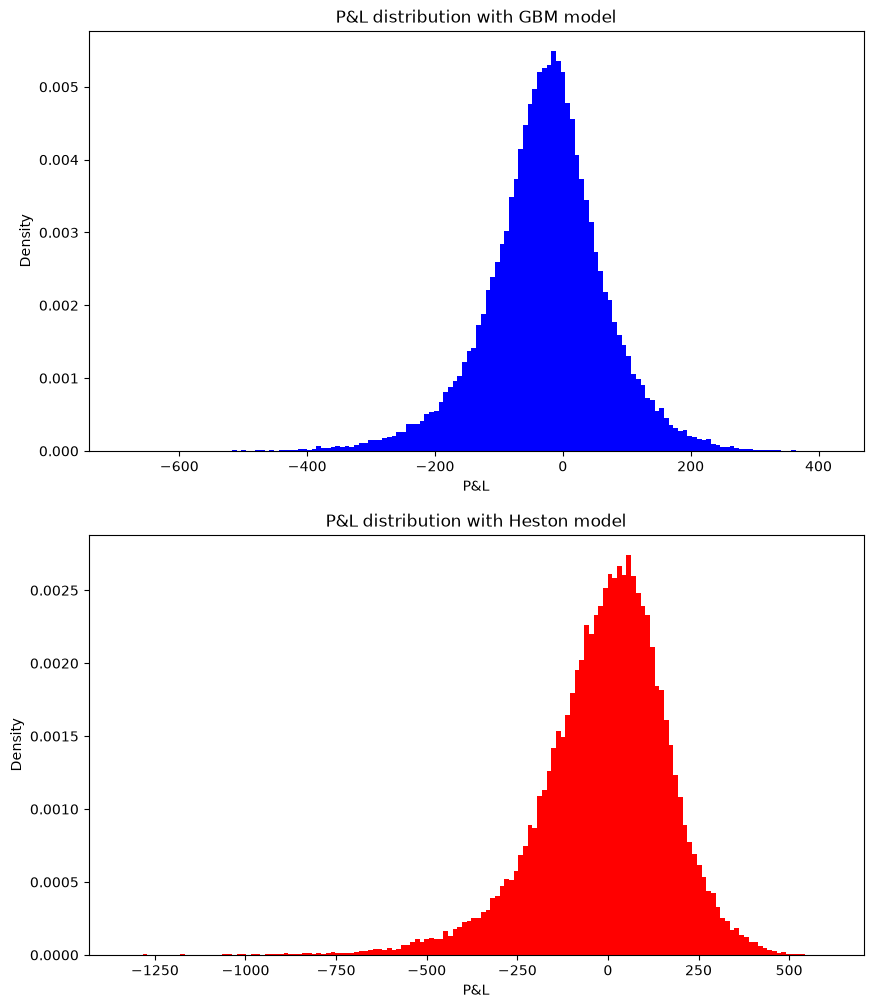

Statistics for P&L distribution with GBM model:

                  0
count  50000.000000
mean     -26.704350
std       92.637724
min     -686.697312
25%      -77.089860
50%      -23.625590
75%       27.317182
max      415.431965


Statistics for P&L distribution with Heston model:

                  0
count  50000.000000
mean      -9.501897
std      176.148695
min    -1335.664419
25%     -104.701446
50%        8.037427
75%      105.069332
max      608.341546


In [43]:
# Plotting PNL distributions of both models 
fig, ax = plt.subplots(2, 1, figsize=(10,12))
ax[0].hist(gbm_pnl, bins=150, color='b', density=True)
ax[1].hist(heston_pnl, bins=150, color='r', density=True)
ax[0].set_title("P&L distribution with GBM model")
ax[1].set_title("P&L distribution with Heston model")

for i in range(2):
    ax[i].set_xlabel("P&L")
    ax[i].set_ylabel("Density")

plt.show()

# Print out some basic statistics using pandas summary 
gbm_pnl_df = pd.DataFrame(gbm_pnl)
heston_pnl_df = pd.DataFrame(heston_pnl)

print("Statistics for P&L distribution with GBM model:\n")
print(gbm_pnl_df.describe())
print("\n")
print("Statistics for P&L distribution with Heston model:\n")
print(heston_pnl_df.describe())

## 4. Replacing delta hedging with deep hedging 

In [84]:
def cvar_np(pnl_distribution, alpha=0.95):
    losses = -np.asarray(pnl_distribution)
    q = np.quantile(losses, alpha)
    return q + np.mean(np.maximum(losses - q, 0.0)) / (1 - alpha)

print("The 0.95-CVaR of the delta hedging portfolio on Heston paths is", cvar_np(heston_pnl))

The 0.95-CVaR of the delta hedging portfolio on Heston paths is 458.2981937220179


In [111]:
# Train the deep hedging model 
COST_RATE = 0.001 # reset cost rate


EPOCHS = 1600
LR = 0.002 # learning rate 

INPUT_SIZE = 3 
HIDDEN_SIZE = 32 
LAYERS = 1
CONFIDENCE_LVL = 0.95

torch.manual_seed(42)
hedgingModel = deephedging.LSTMmodel(INPUT_SIZE, HIDDEN_SIZE, LAYERS, CONFIDENCE_LVL, COST_RATE, UPDATE_INTERVAL)
hedgingModel = torch.compile(hedgingModel)
hedgingModel.trainModel(EPOCHS, LR, paths_per_maturity=30, print_epochs=100)


KeyboardInterrupt: 

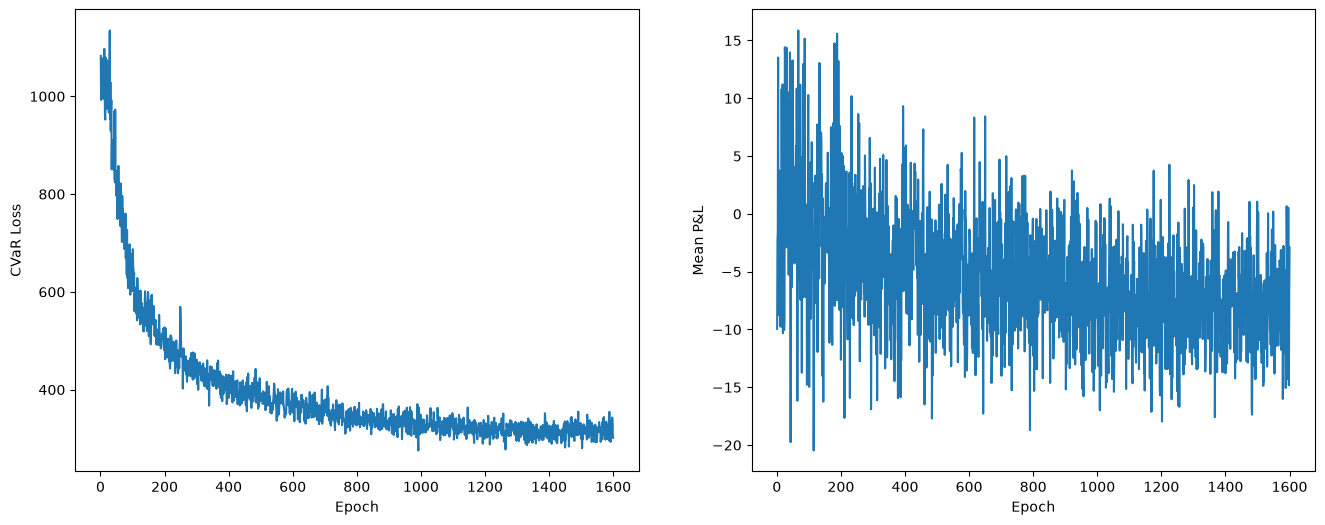

In [71]:
# plot CVaR loss graph over epochs 
fig, ax = plt.subplots(1, 2, figsize=(16,6)) 
ax[0].plot(hedgingModel.train_data['Epoch'], hedgingModel.train_data['CVaR loss'])
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("CVaR Loss") 

ax[1].plot(hedgingModel.train_data['Epoch'], hedgingModel.train_data['Mean P&L'])
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Mean P&L") 

plt.show()

## 5. Model Evaluation


In [72]:
print(hedgingModel.train_data)

      Epoch    CVaR loss   Mean P&L
0         1  1082.800293  -9.946121
1         2   992.699585  -2.240937
2         3  1061.372437  -1.618931
3         4  1008.035522  13.518604
4         5  1075.598389  -5.188107
...     ...          ...        ...
1595   1596   314.635010   0.539560
1596   1597   343.090668  -9.399229
1597   1598   331.582306 -14.817451
1598   1599   305.443970  -6.727391
1599   1600   301.611206  -2.917545

[1600 rows x 3 columns]


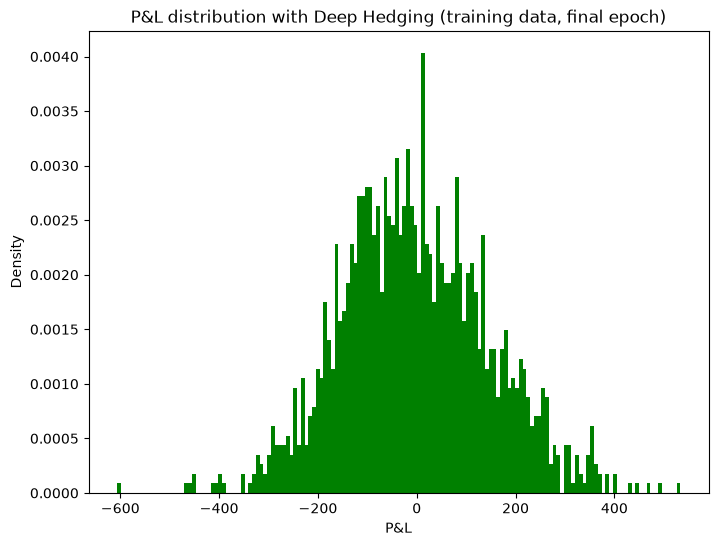

Statistics for P&L distribution with Deep Hedging (training data, final epoch):

                 0
count  1500.000000
mean     -2.917545
std     149.652771
min    -606.998291
25%    -107.243774
50%     -10.853500
75%      95.484663
max     533.632202


In [73]:
# Plotting PNL distribution of deep hedging 
fig, ax = plt.subplots(1, 1, figsize=(8,6))
pnl_dist = hedgingModel.pnl_dist.detach().numpy()
ax.hist(pnl_dist, bins=150, label="PNL distribution with Deep Hedging", color='g', density=True)
ax.set_xlabel("P&L")
ax.set_ylabel("Density")
ax.set_title("P&L distribution with Deep Hedging (training data, final epoch)") 

plt.show()

print("Statistics for P&L distribution with Deep Hedging (training data, final epoch):\n")
print(pd.DataFrame(pnl_dist).describe())


## 6. Test on unseen data 

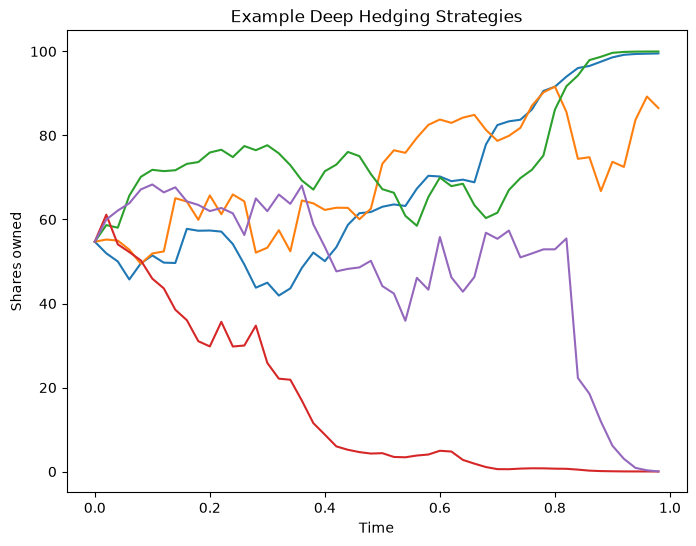

In [74]:
# use model to make predictions 
y_pred_heston = hedgingModel.deep_hedge_on(paths_array_heston)

max_hedge_intervals = int(round(T / hedgingModel.dt))
ts = np.arange(max_hedge_intervals) * hedgingModel.dt       # same 50 hedge times as np.arange(0, T, dt)

fig, ax = plt.subplots(1, 1, figsize=(8,6))
for i in range(5):
    ax.plot(ts, y_pred_heston[i].numpy(), label='Deep Hedge')

ax.set_title("Example Deep Hedging Strategies")
ax.set_xlabel("Time")
ax.set_ylabel("Shares owned")
plt.show()


In [97]:
t2, heston_delta_hedge = deltahedge.delta_hedge_batch(heston_paths, K, R, SIGMA, CALLS_SOLD, T, UPDATE_INTERVAL)

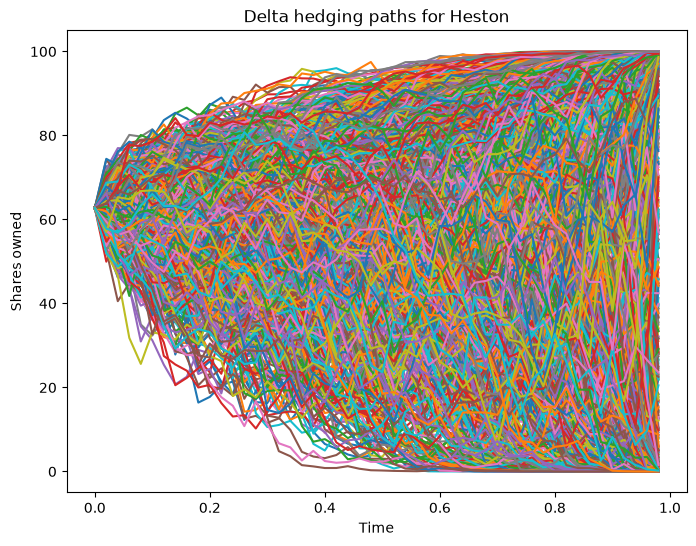

In [98]:
fig, ax = plt.subplots(1, 1, figsize=(8,6))

for i in range(1000):
    ax.plot(t2, heston_delta_hedge[i])

ax.set_title("Delta hedging paths for Heston")
ax.set_xlabel("Time")
ax.set_ylabel("Shares owned")

plt.show()

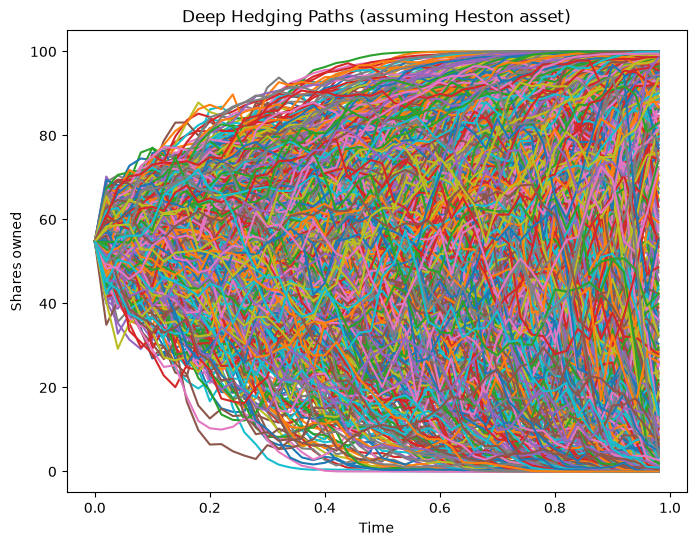

In [79]:
fig, ax = plt.subplots(1, 1, figsize=(8,6))
for i in range(1000):
    ax.plot(ts, y_pred_heston[i].numpy(), label='Deep Hedge')

ax.set_title("Deep Hedging Paths (assuming Heston asset)")
ax.set_xlabel("Time")
ax.set_ylabel("Shares owned")
plt.show()


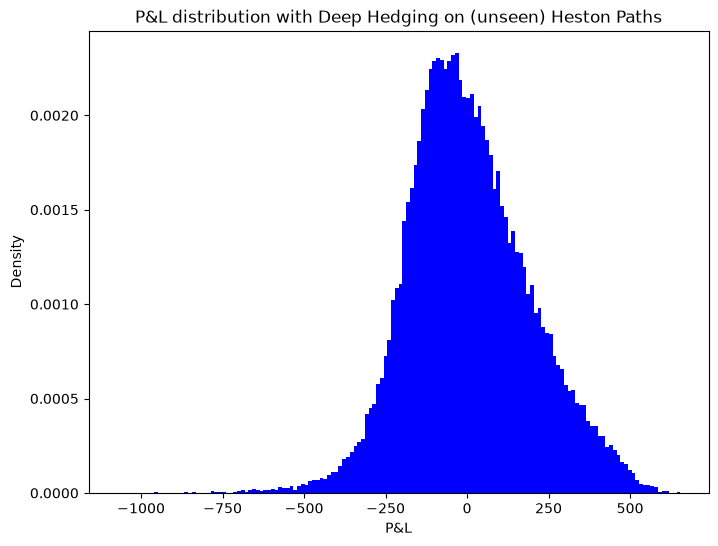

Statistics for P&L distribution with Deep Hedging on Heston Paths:

                  0
count  50000.000000
mean       5.889755
std      188.385590
min    -1074.332886
25%     -121.232819
50%      -10.794736
75%      124.341370
max      654.408691


In [80]:
hedge, paths_heston_resampled, mask = deep_hedge_on(paths_array_heston, trace=True)

C_0 = pricer.option_price_bsm(S_0, K, T, R, SIGMA)
C_0_array = torch.full((paths_heston_resampled.shape[0],), float(C_0))


# recall: syntax hedge_pnl_torch(asset_price_process_array, hedge_process_array, path_mask_array, C_0_array, 
#                                       K, r, no_of_calls, cost_rate, hedging_interval):
deeph_empirical_pnl_heston = deltahedge.hedge_pnl_torch(paths_heston_resampled, hedge, mask, C_0_array, 
                                                         K, R, CALLS_SOLD, COST_RATE, hedgingModel.dt).numpy()


fig, ax = plt.subplots(1, 1, figsize=(8,6))

ax.hist(deeph_empirical_pnl_heston, bins=150, color='b', density=True)
ax.set_xlabel("P&L")
ax.set_ylabel("Density")
ax.set_title("P&L distribution with Deep Hedging on (unseen) Heston Paths") 

plt.show()

print("Statistics for P&L distribution with Deep Hedging on Heston Paths:\n")
print(pd.DataFrame(deeph_empirical_pnl_heston).describe())

For comparison, we recall the statistics for Heston delta hedging were as follows:

In [85]:
print("Statistics for P&L distribution with Heston model:\n")
print(heston_pnl_df.describe())

Statistics for P&L distribution with Heston model:

                  0
count  50000.000000
mean      -9.501897
std      176.148695
min    -1335.664419
25%     -104.701446
50%        8.037427
75%      105.069332
max      608.341546


In [83]:
alphas = [0.75, 0.9, 0.95, 0.99, 0.999]

cvar_data = []

for a in alphas:
    cvar_data.append({
        'CVaR Level': a,
        #'GBM Delta Hedging': cvar_np(gbm_pnl_df, alpha=a),
        'Heston Delta Hedging': cvar_np(heston_pnl_df, alpha=a),
        'Deep Hedging': cvar_np(deeph_empirical_pnl_heston, alpha=a)
    })


cvar_table = pd.DataFrame(cvar_data)

print("CVaR table (lower is better): \n")
display(cvar_table)

CVaR table (lower is better): 



,CVaR Level,Heston Delta Hedging,Deep Hedging
0,0.750,239.560421,218.296280
1,0.900,362.621033,303.368530
2,0.950,458.298194,368.277954
3,0.990,681.499738,534.549194
4,0.999,1016.385121,787.887207


## 7. Comparison to Black-Scholes delta hedge under 0 trading costs (WIP)

In [92]:
COST_RATE = 0.0 # zero costs

EPOCHS = 1600
LR = 0.002 # learning rate 

INPUT_SIZE = 3 
HIDDEN_SIZE = 32 
LAYERS = 1
CONFIDENCE_LVL = 0.95


gbm_generator = lambda rng, n: gbm.geometricBrownianMotion(rng, n, S_0, R, SIGMA, T, STEPS)

torch.manual_seed(42)
hedgingModel_zerocostgbm = deephedging.LSTMmodel(INPUT_SIZE, HIDDEN_SIZE, LAYERS, CONFIDENCE_LVL, COST_RATE, UPDATE_INTERVAL)
hedgingModel_zerocostgbm.trainModel(EPOCHS, LR, paths_per_maturity=30, path_generator=gbm_generator, print_epochs=100)

epoch  100  CVaR loss: 681.7407  mean P&L: -0.3015
epoch  200  CVaR loss: 428.8269  mean P&L: -6.9413
epoch  300  CVaR loss: 366.1039  mean P&L: -3.2820
epoch  400  CVaR loss: 300.5968  mean P&L: 4.7980
epoch  500  CVaR loss: 287.4278  mean P&L: -0.8758
epoch  600  CVaR loss: 284.5917  mean P&L: 0.9284
epoch  700  CVaR loss: 273.8379  mean P&L: 2.3594
epoch  800  CVaR loss: 240.4582  mean P&L: -5.3846
epoch  900  CVaR loss: 225.5163  mean P&L: 2.1534
epoch 1000  CVaR loss: 235.4058  mean P&L: -0.4671
epoch 1100  CVaR loss: 220.7702  mean P&L: -3.1979
epoch 1200  CVaR loss: 199.2866  mean P&L: -3.2250
epoch 1300  CVaR loss: 207.4996  mean P&L: 1.3785
epoch 1400  CVaR loss: 219.8404  mean P&L: 0.0362
epoch 1500  CVaR loss: 203.7969  mean P&L: -2.4045
epoch 1600  CVaR loss: 206.3799  mean P&L: 2.7922
Training complete.


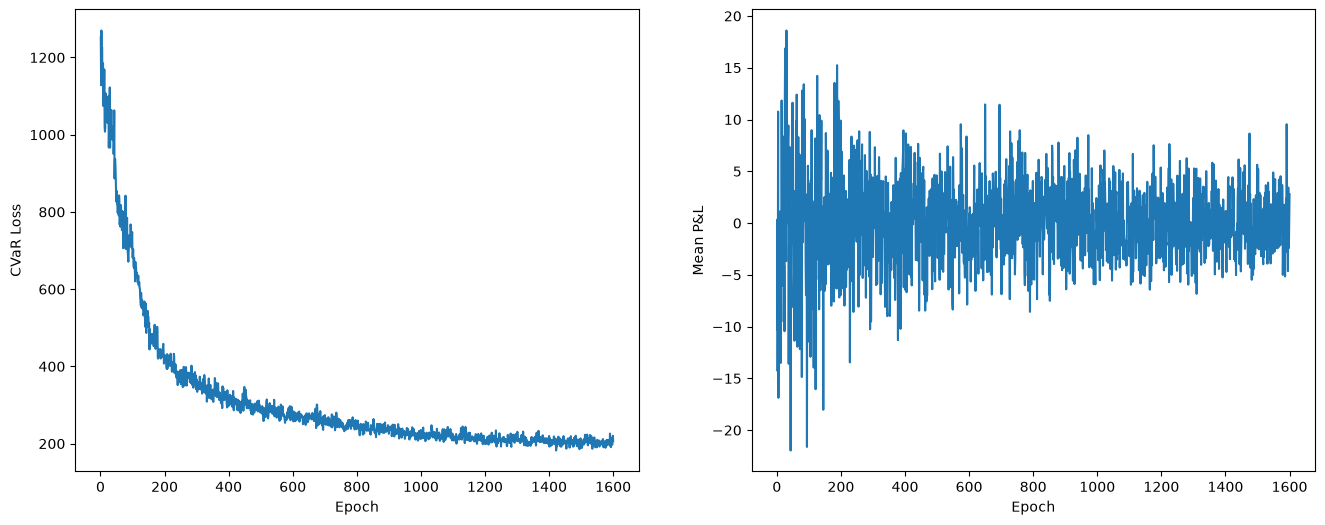

In [93]:
# plot CVaR loss graph over epochs 
fig, ax = plt.subplots(1, 2, figsize=(16,6)) 
ax[0].plot(hedgingModel_zerocostgbm.train_data['Epoch'], hedgingModel_zerocostgbm.train_data['CVaR loss'])
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("CVaR Loss") 

ax[1].plot(hedgingModel_zerocostgbm.train_data['Epoch'], hedgingModel_zerocostgbm.train_data['Mean P&L'])
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("Mean P&L") 

plt.show()

In [99]:
t, gbm_delta_hedge = deltahedge.delta_hedge_batch(paths_array_gbm, K, R, SIGMA, CALLS_SOLD, T, UPDATE_INTERVAL)

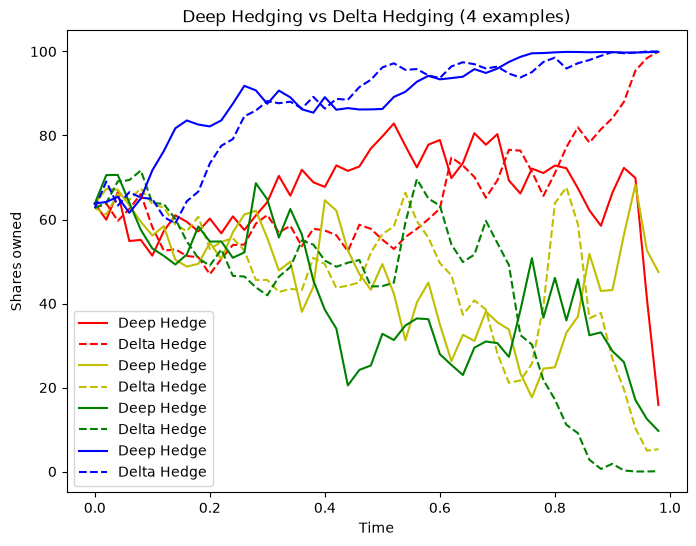

In [112]:
# use model to make predictions 
gbm_pred = hedgingModel_zerocostgbm.deep_hedge_on(paths_array_gbm[:1000])

max_hedge_intervals = int(round(T / hedgingModel.dt))
ts = np.arange(max_hedge_intervals) * hedgingModel.dt       # same 50 hedge times as np.arange(0, T, dt)

fig, ax = plt.subplots(1, 1, figsize=(8,6))

colours = ['r', 'y', 'g', 'b']

for i, col in enumerate(colours):
    ax.plot(ts, gbm_pred[i].numpy(), label='Deep Hedge', color=col, linestyle='solid')
    ax.plot(t, gbm_delta_hedge[i], label='Delta Hedge', color=col, linestyle='dashed')

ax.set_title("Deep Hedging vs Delta Hedging (4 examples)")
ax.set_xlabel("Time")
ax.set_ylabel("Shares owned")
ax.legend()
plt.show()




In [113]:
def cvar_np(pnl, alpha=0.95):
    losses = -np.asarray(pnl)
    q = np.quantile(losses, alpha)
    return q + np.mean(np.maximum(losses - q, 0.0)) / (1 - alpha)

def bs_delta_hedge_process(prices_hedge, intervals_to_maturity, dt, no_of_calls):
    prices = prices_hedge.detach().numpy() if torch.is_tensor(prices_hedge) else np.asarray(prices_hedge)
    n = intervals_to_maturity.detach().numpy() if torch.is_tensor(intervals_to_maturity) else np.asarray(intervals_to_maturity)
    col = np.arange(prices.shape[1])[None, :]
    col_frozen = np.minimum(col, n[:, None] - 1)            # position frozen after the last decision date
    S_at = np.take_along_axis(prices, col_frozen, axis=1)
    tau = (n[:, None] - col_frozen) * dt                    # always >= dt, so no division by zero
    return torch.from_numpy(bsm_delta(S_at, K, R, SIGMA, tau) * no_of_calls).float()

In [114]:
def path_policy_diagnostic(model, prices, iv, max_points=40000, seed=0):
    prices_t = torch.from_numpy(prices).float()
    with torch.no_grad():
        net_delta, active = model.simulate_process(prices_t, 1, torch.from_numpy(iv))  # no_of_calls=1 -> raw delta
    net_delta, active = net_delta.numpy(), active.numpy()

    n_points = prices.shape[1]
    step_index = np.broadcast_to(np.arange(n_points)[None, :], active.shape)
    tau = (iv[:, None] - np.arange(n_points)[None, :]) * model.dt     # > 0 wherever active

    S_a, tau_a, step_a = prices[active], tau[active], step_index[active]
    d_nn = net_delta[active]
    d_bs = bsm_delta(S_a, K, R, SIGMA, tau_a)
    resid = d_nn - d_bs

    print(f"mean |residual| all steps: {np.abs(resid).mean():.4f}   "
          f"excluding step 0: {np.abs(resid[step_a > 0]).mean():.4f}   "
          f"step 0 only: {np.abs(resid[step_a == 0]).mean():.4f}")

    rng = np.random.default_rng(seed)
    pick = rng.choice(len(d_bs), size=min(max_points, len(d_bs)), replace=False)
    fig, ax = plt.subplots(1, 3, figsize=(17, 5))

    sc = ax[0].scatter(d_bs[pick], d_nn[pick], c=tau_a[pick], s=2, alpha=0.3)
    ax[0].plot([0, 1], [0, 1], 'k--'); fig.colorbar(sc, ax=ax[0], label="tau")
    ax[0].set_xlabel("delta_BS"); ax[0].set_ylabel("delta_theta"); ax[0].set_title("Along paths")

    steps = np.arange(n_points)
    ax[1].plot(steps, [np.abs(resid[step_a == s]).mean() if (step_a == s).any() else np.nan for s in steps])
    ax[1].set_xlabel("hedge step since inception"); ax[1].set_ylabel("mean |residual|"); ax[1].set_title("Residual by step")

    bins = np.linspace(0, T, 11); which = np.digitize(tau_a, bins)
    ax[2].plot(0.5 * (bins[:-1] + bins[1:]), [np.abs(resid[which == b]).mean() for b in range(1, 11)], 'o-')
    ax[2].set_xlabel("tau (time to maturity)"); ax[2].set_ylabel("mean |residual|"); ax[2].set_title("Residual by tau")
    plt.tight_layout(); plt.show()

iv, prices, pnl = evaluate_on_common_batch(hedgingModel_zerocostgbm, gbm_generator)
for name, p in pnl.items():
    print(f"{name:9s} mean {p.mean():7.2f}  CVaR95 {cvar_np(p):7.1f}  T=1-only CVaR95 {cvar_np(p[iv == iv.max()]):7.1f}")
path_policy_diagnostic(hedgingModel_zerocostgbm, prices, iv)

NameError: name 'evaluate_on_common_batch' is not defined

In [56]:
def delta_prev_sensitivity(model, prices, iv, probe_steps=(5, 15, 30), eps=0.1):
    prices_t = torch.from_numpy(prices).float(); iv_t = torch.from_numpy(iv)
    hidden = model.init_hidden_layer(len(iv)); delta_prev = torch.zeros(len(iv))
    clone = lambda hc: ([h.clone() for h in hc[0]], [c.clone() for c in hc[1]])
    with torch.no_grad():
        for i in range(prices_t.shape[1]):
            active = i < iv_t
            tau = ((iv_t - i) * model.dt).clamp(min=1e-6)
            S_i = prices_t[:, i]
            if i in probe_steps:
                up, _ = model.step(S_i, tau, (delta_prev + eps).clamp(0, 1), clone(hidden))
                dn, _ = model.step(S_i, tau, (delta_prev - eps).clamp(0, 1), clone(hidden))
                sens = ((up - dn) / (2 * eps))[active]
                print(f"step {i}: mean |d delta_out / d delta_prev| = {sens.abs().mean():.4f}")
            new, hidden = model.step(S_i, tau, delta_prev, hidden)
            delta_prev = torch.where(active, new, delta_prev)

delta_prev_sensitivity(hedgingModel_zerocostgbm, prices, iv)

step 5: mean |d delta_out / d delta_prev| = 0.0847
step 15: mean |d delta_out / d delta_prev| = 0.0734
step 30: mean |d delta_out / d delta_prev| = 0.0586
